In [1]:
# ── CELL 1: Imports ──────────────────────────────────────────────────────────
import os, sys, json, re
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
sys.path.append(os.path.abspath(".."))

print("imports OK")

imports OK


In [2]:
# ── CELL 2: Paths ────────────────────────────────────────────────────────────
ROOT          = Path("/scratch/network/cr7998/cv_emergence_project")
FB_ROOT       = ROOT / "data" / "FunnyBirds"

BASELINE_JSON = ROOT / "results" / "probes" / "resnet50_funnybirds_probes_fine.json"
CBM_JSON      = ROOT / "results" / "probes" / "resnet50_funnybirds_cbm_probes_fine.json"

BASELINE_FEAT_DIR = ROOT / "features" / "resnet50_funnybirds"
CBM_FEAT_DIR      = ROOT / "features" / "resnet50_cbm_funnybirds"   # was resnet50_funnybirds_cbm

for name, p in [("FB_ROOT", FB_ROOT),
                ("BASELINE_JSON", BASELINE_JSON),
                ("CBM_JSON", CBM_JSON),
                ("BASELINE_FEAT_DIR", BASELINE_FEAT_DIR),
                ("CBM_FEAT_DIR", CBM_FEAT_DIR)]:
    print(f"{name}: {p}  exists={p.exists()}")

FB_ROOT: /scratch/network/cr7998/cv_emergence_project/data/FunnyBirds  exists=True
BASELINE_JSON: /scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_funnybirds_probes_fine.json  exists=False
CBM_JSON: /scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_funnybirds_cbm_probes_fine.json  exists=False
BASELINE_FEAT_DIR: /scratch/network/cr7998/cv_emergence_project/features/resnet50_funnybirds  exists=True
CBM_FEAT_DIR: /scratch/network/cr7998/cv_emergence_project/features/resnet50_cbm_funnybirds  exists=True


In [3]:
# ── CELL 3: Discover FunnyBirds file structure ───────────────────────────────
# Walk FB_ROOT to understand what's there before loading anything
print("=== Top-level contents ===")
for p in sorted(FB_ROOT.iterdir()):
    n = len(list(p.rglob("*"))) if p.is_dir() else "-"
    print(f"  {'DIR' if p.is_dir() else 'FILE'} {p.name}   ({n} items)" )

print()
print("=== JSON files ===")
for p in sorted(FB_ROOT.rglob("*.json"))[:20]:
    print(f"  {p.relative_to(FB_ROOT)}  ({p.stat().st_size//1024} KB)")

print()
print("=== Image sample ===")
imgs = sorted(FB_ROOT.rglob("*.png"))[:5] + sorted(FB_ROOT.rglob("*.jpg"))[:5]
for p in imgs:
    print(f"  {p.relative_to(FB_ROOT)}")

print()
print("=== Class subdirectories (first 10) ===")
for d in sorted([x for x in FB_ROOT.rglob("*") if x.is_dir()])[:15]:
    print(f"  {d.relative_to(FB_ROOT)}")

=== Top-level contents ===
  FILE classes.json   (- items)
  FILE dataset_test.json   (- items)
  FILE dataset_train.json   (- items)
  DIR metadata   (5 items)
  FILE parts.json   (- items)
  DIR test   (550 items)
  DIR test_interventions   (25677 items)
  DIR test_part_map   (550 items)
  DIR train   (50050 items)
  DIR train_part_map   (50050 items)

=== JSON files ===
  classes.json  (4 KB)
  dataset_test.json  (1233 KB)
  dataset_train.json  (122605 KB)
  parts.json  (1 KB)

=== Image sample ===
  test/0/000000.png
  test/0/000001.png
  test/0/000002.png
  test/0/000003.png
  test/0/000004.png

=== Class subdirectories (first 10) ===
  metadata
  test
  test/0
  test/1
  test/10
  test/11
  test/12
  test/13
  test/14
  test/15
  test/16
  test/17
  test/18
  test/19
  test/2


In [4]:
# ── CELL 4: Load FunnyBirds ground truth ─────────────────────────────────────
def load_fb_json(path: Path, split: str) -> list:
    assert path.exists(), f"Missing: {path}"
    with path.open() as f:
        data = json.load(f)
    assert isinstance(data, list), f"Expected list in {path}, got {type(data)}"
    for rec in data:
        rec["_split"] = split          # tag split before parsing
    return data

train_json = FB_ROOT / "dataset_train.json"
test_json  = FB_ROOT / "dataset_test.json"

assert train_json.exists(), f"Missing {train_json}"
assert test_json.exists(),  f"Missing {test_json}"

raw_gt = load_fb_json(train_json, "train") + load_fb_json(test_json, "test")
records = raw_gt

print(f"Total records: {len(records)}")
print(f"Train: {sum(1 for r in records if r['_split']=='train')}")
print(f"Test:  {sum(1 for r in records if r['_split']=='test')}")
print()
print("First record keys:", list(records[0].keys()))
print(json.dumps({k: v for k, v in records[0].items() if not k.startswith("bg_") or k == "bg_color"}, indent=2))

Total records: 50500
Train: 50000
Test:  500

First record keys: ['class_idx', 'camera_distance', 'camera_pitch', 'camera_roll', 'light_distance', 'light_pitch', 'light_roll', 'beak_model', 'beak_color', 'eye_model', 'foot_model', 'tail_model', 'tail_color', 'wing_model', 'wing_color', 'bg_objects', 'bg_radius', 'bg_pitch', 'bg_roll', 'bg_scale_x', 'bg_scale_y', 'bg_scale_z', 'bg_rot_x', 'bg_rot_y', 'bg_rot_z', 'bg_color', '_split']
{
  "class_idx": 0,
  "camera_distance": 362,
  "camera_pitch": 6.148547646933539,
  "camera_roll": 5.261843443092755,
  "light_distance": 300,
  "light_pitch": 0.8200923534413885,
  "light_roll": 0.09254683805404124,
  "beak_model": "placeholder",
  "beak_color": "placeholder",
  "eye_model": "placeholder",
  "foot_model": "foot01.glb",
  "tail_model": "tail02.glb",
  "tail_color": "green",
  "wing_model": "wing01.glb",
  "wing_color": "blue",
  "bg_color": "",
  "_split": "train"
}


In [5]:
# ── CELL 5: Parse GT into a flat DataFrame ───────────────────────────────────
# Structure: flat keys like beak_model, beak_color, tail_model, tail_color, etc.

PART_NAMES   = ["beak", "eye", "foot", "tail", "wing"]   # "foot" not "feet"
PART_ATTRS   = ["model", "color"]                         # suffixes after part_

def _parse_record(rec: dict, img_idx: int):
    rows = []

    class_id = rec.get("class_idx", rec.get("class_id", rec.get("class", -1)))
    split    = rec.get("_split", "unknown")

    base = {"image_id": img_idx, "class_id": int(class_id), "split": split}

    for part_name in PART_NAMES:
        for attr in PART_ATTRS:
            key = f"{part_name}_{attr}"
            if key in rec and rec[key] != "" and rec[key] is not None:
                rows.append({**base, "part": part_name,
                              "attribute": attr, "value": str(rec[key])})

    bg_color = rec.get("bg_color", "")
    if bg_color and bg_color != "":
        rows.append({**base, "part": "background",
                     "attribute": "color", "value": str(bg_color)})

    if not rows:
        rows.append(base)   # fallback: at least keep the image row

    return rows

all_rows = []
for i, rec in enumerate(records):
    all_rows.extend(_parse_record(rec, i))

gt_long = pd.DataFrame(all_rows)
print("gt_long shape:", gt_long.shape)
print("Columns:", list(gt_long.columns))
print("Splits:", gt_long["split"].value_counts().to_dict())
print("Unique classes:", gt_long["class_id"].nunique())
if "part" in gt_long.columns:
    print("Parts found:", sorted(gt_long["part"].unique().tolist()))
    print("Values per part:")
    for p in sorted(gt_long["part"].unique()):
        vals = gt_long[gt_long["part"]==p]["value"].unique()
        print(f"  {p}: {sorted(vals)[:8]}")
gt_long.head(10)

gt_long shape: (453091, 6)
Columns: ['image_id', 'class_id', 'split', 'part', 'attribute', 'value']
Splits: {'train': 448600, 'test': 4491}
Unique classes: 50
Parts found: ['background', 'beak', 'eye', 'foot', 'tail', 'wing']
Values per part:
  background: ['blue,', 'blue,blue,', 'blue,blue,blue,', 'blue,blue,blue,blue,', 'blue,blue,blue,blue,blue,blue,green,blue,green,blue,red,', 'blue,blue,blue,blue,blue,blue,green,yellow,red,yellow,yellow,yellow,blue,green,red,red,green,blue,', 'blue,blue,blue,blue,blue,blue,red,green,blue,blue,blue,yellow,green,red,red,blue,blue,', 'blue,blue,blue,blue,blue,blue,yellow,green,blue,red,green,green,blue,yellow,green,red,yellow,yellow,green,green,green,yellow,yellow,green,yellow,red,green,blue,blue,green,']
  beak: ['beak01.glb', 'beak02.glb', 'beak03.glb', 'beak04.glb', 'placeholder', 'yellow']
  eye: ['eye01.glb', 'eye02.glb', 'eye03.glb', 'placeholder']
  foot: ['foot01.glb', 'foot02.glb', 'foot03.glb', 'foot04.glb', 'placeholder']
  tail: ['blue', 

,image_id,class_id,split,part,attribute,value
0,0,0,train,beak,model,placeholder
1,0,0,train,beak,color,placeholder
2,0,0,train,eye,model,placeholder
3,0,0,train,foot,model,foot01.glb
4,0,0,train,tail,model,tail02.glb
5,0,0,train,tail,color,green
6,0,0,train,wing,model,wing01.glb
7,0,0,train,wing,color,blue
8,1,0,train,beak,model,beak04.glb
9,1,0,train,beak,color,yellow


In [6]:
# ── CELL 6: Build image-level summary (one row per image) ────────────────────
#
# img_df: image_id | filename | class_id | split
# class_part_df: class_id | part | attribute | value  (deterministic per class)

img_df = (
    gt_long[["image_id", "class_id", "split"]]
    .drop_duplicates("image_id")
    .sort_values("image_id")
    .reset_index(drop=True)
)

# class_part_df: most common value per (class, part, attribute)
class_part_df = (
    gt_long[gt_long["part"] != "background"]   # exclude bg from class structure
    .groupby(["class_id", "part", "attribute"])["value"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Total images:", len(img_df))
print("Train images:", (img_df["split"]=="train").sum())
print("Test images: ", (img_df["split"]=="test").sum())
print("Classes:", img_df["class_id"].nunique())
display(class_part_df.head(20))

Total images: 50500
Train images: 50000
Test images:  500
Classes: 50


,class_id,part,attribute,value
0,0,beak,color,yellow
1,0,beak,model,beak04.glb
2,0,eye,model,eye02.glb
3,0,foot,model,foot01.glb
4,0,tail,color,green
5,0,tail,model,tail02.glb
6,0,wing,color,blue
7,0,wing,model,wing01.glb
8,1,beak,color,yellow
9,1,beak,model,beak04.glb


In [7]:
# ── CELL 7: Part attribute vocabulary ────────────────────────────────────────
print("=" * 60)
for part in gt_long["part"].unique():
    sub = gt_long[gt_long["part"] == part]
    for attr in sub["attribute"].unique():
        vals = sorted(sub[sub["attribute"]==attr]["value"].unique())
        print(f"  {part}.{attr}: {len(vals)} values →  {vals[:10]}")
print("=" * 60)

  beak.model: 5 values →  ['beak01.glb', 'beak02.glb', 'beak03.glb', 'beak04.glb', 'placeholder']
  beak.color: 2 values →  ['placeholder', 'yellow']
  eye.model: 4 values →  ['eye01.glb', 'eye02.glb', 'eye03.glb', 'placeholder']
  foot.model: 5 values →  ['foot01.glb', 'foot02.glb', 'foot03.glb', 'foot04.glb', 'placeholder']
  tail.model: 4 values →  ['placeholder', 'tail01.glb', 'tail02.glb', 'tail03.glb']
  tail.color: 4 values →  ['blue', 'green', 'placeholder', 'red']
  wing.model: 3 values →  ['placeholder', 'wing01.glb', 'wing02.glb']
  wing.color: 4 values →  ['blue', 'green', 'placeholder', 'red']
  background.color: 42739 values →  ['blue,', 'blue,blue,', 'blue,blue,blue,', 'blue,blue,blue,blue,', 'blue,blue,blue,blue,blue,blue,green,blue,green,blue,red,', 'blue,blue,blue,blue,blue,blue,green,yellow,red,yellow,yellow,yellow,blue,green,red,red,green,blue,', 'blue,blue,blue,blue,blue,blue,red,green,blue,blue,blue,yellow,green,red,red,blue,blue,', 'blue,blue,blue,blue,blue,blue,

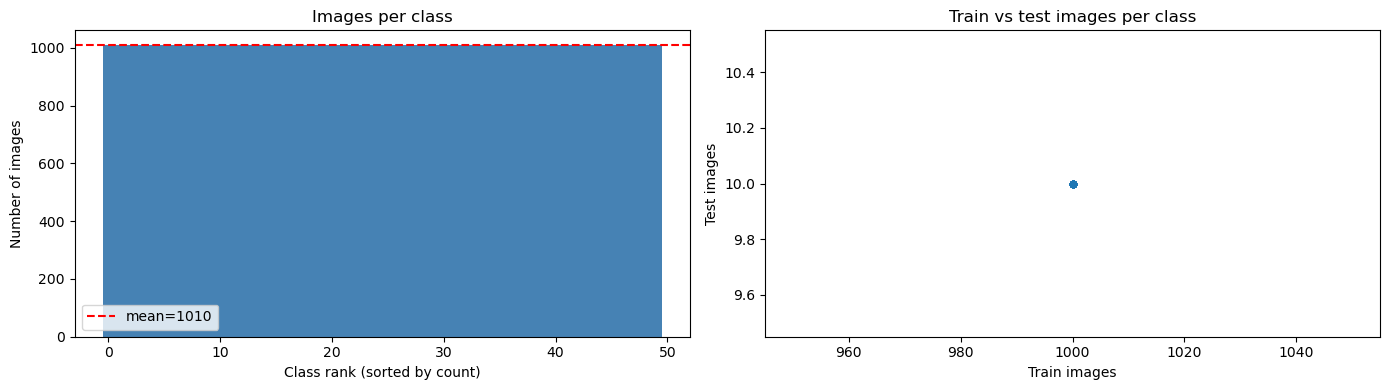

Class size stats:
count      50.0
mean     1010.0
std         0.0
min      1010.0
25%      1010.0
50%      1010.0
75%      1010.0
max      1010.0
dtype: float64


In [8]:
# ── CELL 8: Per-class images & balance ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Total images per class
per_class = img_df.groupby("class_id").size().sort_values()
axes[0].bar(range(len(per_class)), per_class.values, color="steelblue", width=1.0)
axes[0].set_xlabel("Class rank (sorted by count)")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Images per class")
axes[0].axhline(per_class.mean(), color="red", ls="--", label=f"mean={per_class.mean():.0f}")
axes[0].legend()

# Per-split breakdown
split_class = img_df.groupby(["class_id","split"]).size().unstack(fill_value=0)
if "train" in split_class and "test" in split_class:
    axes[1].scatter(split_class["train"], split_class["test"], alpha=0.6, s=20)
    axes[1].set_xlabel("Train images")
    axes[1].set_ylabel("Test images")
    axes[1].set_title("Train vs test images per class")
else:
    split_class.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Images per class by split")

plt.tight_layout()
plt.show()

print("Class size stats:")
print(per_class.describe().round(1))

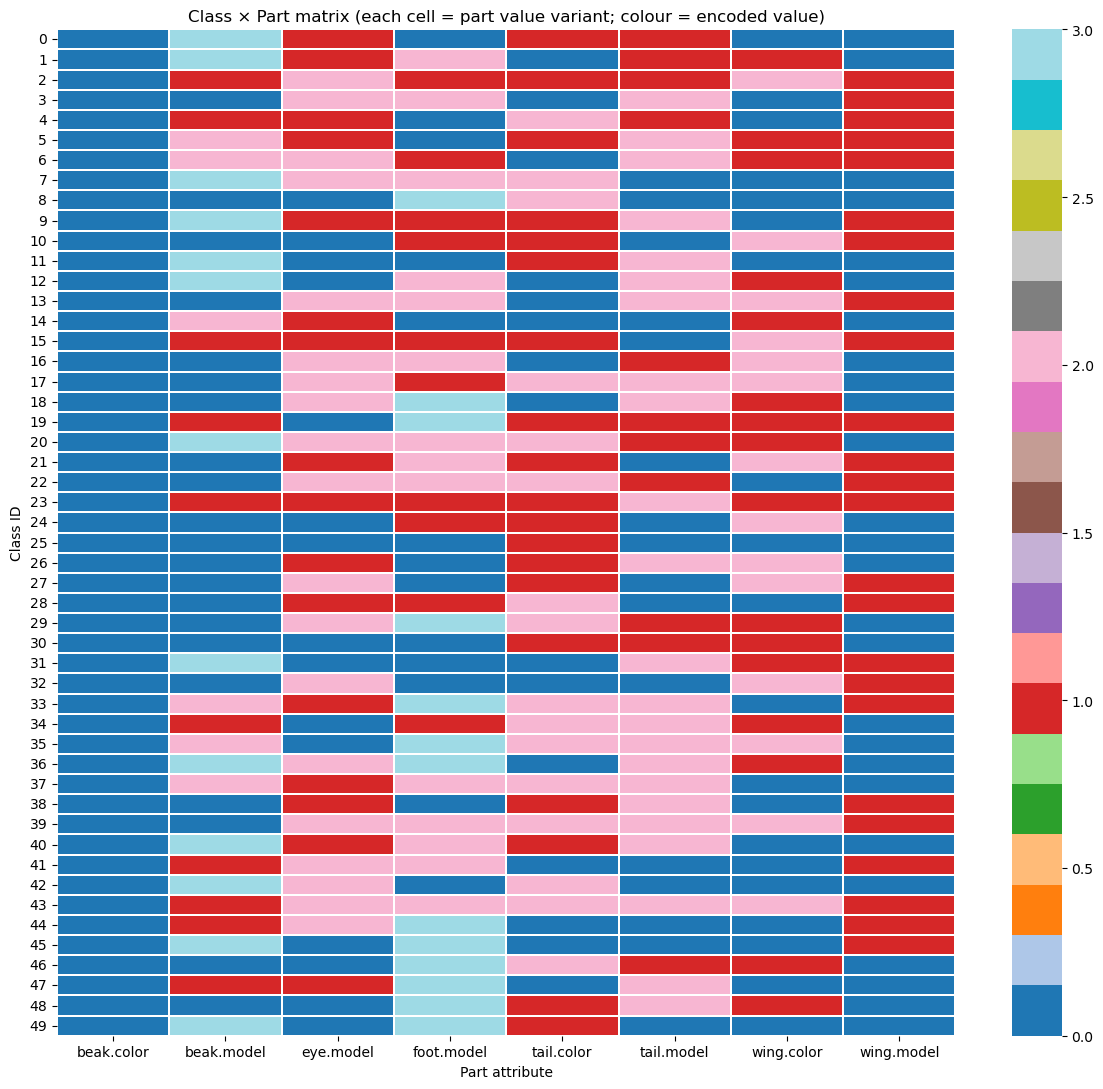

class_wide shape: (50, 8)


part_attr,beak.color,beak.model,eye.model,foot.model,tail.color,tail.model,wing.color,wing.model
class_id,,,,,,,,
0,yellow,beak04.glb,eye02.glb,foot01.glb,green,tail02.glb,blue,wing01.glb
1,yellow,beak04.glb,eye02.glb,foot03.glb,blue,tail02.glb,green,wing01.glb
2,yellow,beak02.glb,eye03.glb,foot02.glb,green,tail02.glb,red,wing02.glb
3,yellow,beak01.glb,eye03.glb,foot03.glb,blue,tail03.glb,blue,wing02.glb
4,yellow,beak02.glb,eye02.glb,foot01.glb,red,tail02.glb,blue,wing02.glb


In [9]:
# ── CELL 9: Class-Part matrix — what defines each class ──────────────────────
#
# Unique to FunnyBirds: each class is deterministically defined by its parts.
# We pivot class_part_df into a wide matrix for visualization.

pivot_rows = []
for _, row in class_part_df.iterrows():
    pivot_rows.append({
        "class_id": int(row["class_id"]),
        "part_attr": f"{row['part']}.{row['attribute']}",
        "value": row["value"],
    })
class_wide = pd.DataFrame(pivot_rows).pivot(index="class_id", columns="part_attr", values="value")

# Encode values as integers for heatmap
class_coded = class_wide.copy()
for col in class_coded.columns:
    cats = pd.Categorical(class_coded[col])
    class_coded[col] = cats.codes

fig, ax = plt.subplots(figsize=(max(12, len(class_coded.columns)*0.6), max(8, len(class_coded)*0.22)))
sns.heatmap(
    class_coded.astype(float),
    ax=ax,
    cmap="tab20",
    linewidths=0.3,
    linecolor="white",
    cbar=True,
    yticklabels=True,
    xticklabels=True,
)
ax.set_title("Class × Part matrix (each cell = part value variant; colour = encoded value)")
ax.set_xlabel("Part attribute")
ax.set_ylabel("Class ID")
plt.tight_layout()
plt.show()

print("class_wide shape:", class_wide.shape)
display(class_wide.head())

/tmp/ipykernel_2923233/1600100733.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_part, labels=parts_order, patch_artist=True)


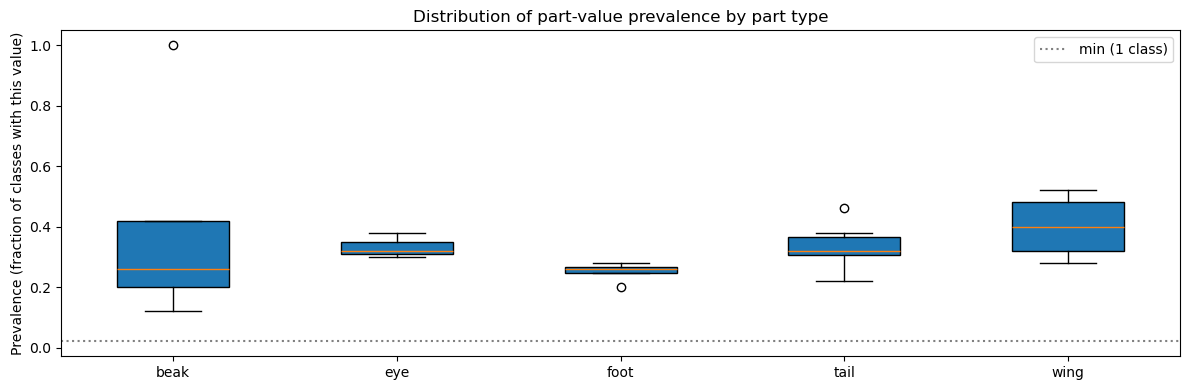

Part value frequency table (sorted by rarity):


,part_attr,part,attribute,value,n_classes,prevalence
4,beak.model,beak,model,beak03.glb,6,0.12
3,beak.model,beak,model,beak02.glb,10,0.20
11,foot.model,foot,model,foot02.glb,10,0.20
17,tail.model,tail,model,tail02.glb,11,0.22
10,foot.model,foot,model,foot04.glb,13,0.26
2,beak.model,beak,model,beak04.glb,13,0.26
9,foot.model,foot,model,foot01.glb,13,0.26
20,wing.color,wing,color,red,14,0.28
8,foot.model,foot,model,foot03.glb,14,0.28
14,tail.color,tail,color,blue,15,0.30


In [10]:
# ── CELL 10: Part value frequency across classes ─────────────────────────────
#
# "Prevalence" of a part value = fraction of classes that have it.
# Low prevalence = rare = more discriminative.

part_val_counts = []
for col in class_wide.columns:
    vc = class_wide[col].value_counts()
    for val, cnt in vc.items():
        part_val_counts.append({
            "part_attr": col,
            "part": col.split(".")[0],
            "attribute": col.split(".")[1] if "." in col else col,
            "value": val,
            "n_classes": cnt,
            "prevalence": cnt / class_wide.shape[0],
        })

pvc_df = pd.DataFrame(part_val_counts).sort_values(["part_attr", "n_classes"])

# plot: distribution of prevalences by part type
fig, ax = plt.subplots(figsize=(12, 4))
parts_order = sorted(pvc_df["part"].unique())
data_by_part = [pvc_df[pvc_df["part"]==p]["prevalence"].values for p in parts_order]
ax.boxplot(data_by_part, labels=parts_order, patch_artist=True)
ax.set_ylabel("Prevalence (fraction of classes with this value)")
ax.set_title("Distribution of part-value prevalence by part type")
ax.axhline(1.0/class_wide.shape[0], color="grey", ls=":", label="min (1 class)")
ax.legend()
plt.tight_layout()
plt.show()

print("Part value frequency table (sorted by rarity):")
display(pvc_df.sort_values("n_classes").head(30))

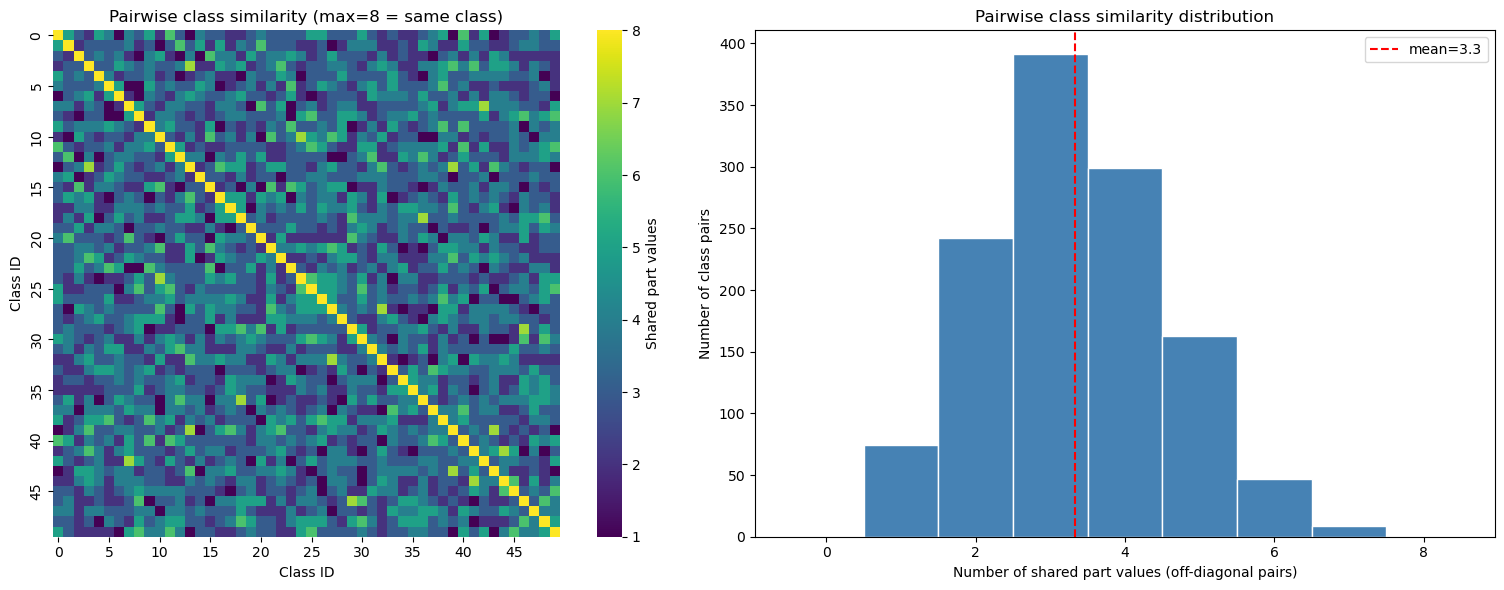

Off-diagonal similarity stats:
count    1225.00
mean        3.34
std         1.25
min         1.00
25%         2.00
50%         3.00
75%         4.00
max         7.00
dtype: float64
Most similar non-identical pair: 7 shared out of 8


In [11]:
# ── CELL 11: Pairwise class similarity ───────────────────────────────────────
#
# How many part values do two classes share?
# Range: 0 (totally different) to n_part_attrs (identical — shouldn't happen).

classes = sorted(class_wide.index.tolist())
n_cls = len(classes)
n_attrs = class_wide.shape[1]

sim_matrix = np.zeros((n_cls, n_cls), dtype=int)
for i, ci in enumerate(classes):
    for j, cj in enumerate(classes):
        sim_matrix[i, j] = (class_wide.loc[ci] == class_wide.loc[cj]).sum()

sim_df = pd.DataFrame(sim_matrix, index=classes, columns=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(sim_df, ax=axes[0], cmap="viridis", square=True,
            xticklabels=5, yticklabels=5,
            cbar_kws={"label": "Shared part values"})
axes[0].set_title(f"Pairwise class similarity (max={n_attrs} = same class)")
axes[0].set_xlabel("Class ID")
axes[0].set_ylabel("Class ID")

# Histogram of off-diagonal similarities
off_diag = sim_matrix[np.triu_indices(n_cls, k=1)]
axes[1].hist(off_diag, bins=range(0, n_attrs+2), align="left",
             color="steelblue", edgecolor="white")
axes[1].set_xlabel("Number of shared part values (off-diagonal pairs)")
axes[1].set_ylabel("Number of class pairs")
axes[1].set_title("Pairwise class similarity distribution")
axes[1].axvline(off_diag.mean(), color="red", ls="--", label=f"mean={off_diag.mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Off-diagonal similarity stats:")
print(pd.Series(off_diag).describe().round(2))
print(f"Most similar non-identical pair: {off_diag.max()} shared out of {n_attrs}")

In [12]:
# ── CELL 12: Most confusable class pairs ─────────────────────────────────────
#
# Which pairs of classes share the most parts?  These are the "hard" pairs.

pair_rows = []
for i, ci in enumerate(classes):
    for j, cj in enumerate(classes):
        if j <= i:
            continue
        shared = int(sim_matrix[i, j])
        # which parts differ?
        diff_cols = [c for c in class_wide.columns if class_wide.loc[ci, c] != class_wide.loc[cj, c]]
        pair_rows.append({
            "class_A": ci, "class_B": cj,
            "shared": shared,
            "differ_on": n_attrs - shared,
            "diff_parts": ", ".join(diff_cols[:6]),
        })

pair_df = pd.DataFrame(pair_rows).sort_values("shared", ascending=False)

print("Top 20 most similar class pairs (most shared parts):")
display(pair_df.head(20))
print()
print("Top 10 most different class pairs:")
display(pair_df.tail(10))

Top 20 most similar class pairs (most shared parts):


,class_A,class_B,shared,differ_on,diff_parts
976,27,32,7,1,tail.color
1191,41,44,7,1,foot.model
458,10,24,7,1,wing.model
1173,39,43,7,1,beak.model
153,3,13,7,1,wing.color
356,7,42,7,1,foot.model
746,18,36,7,1,beak.model
584,13,39,7,1,tail.color
1031,29,46,7,1,eye.model
404,8,49,6,2,"beak.model, tail.color"



Top 10 most different class pairs:


,class_A,class_B,shared,differ_on,diff_parts
632,15,18,1,7,"beak.model, eye.model, foot.model, tail.color,..."
634,15,20,1,7,"beak.model, eye.model, foot.model, tail.color,..."
643,15,29,1,7,"beak.model, eye.model, foot.model, tail.color,..."
1079,32,40,1,7,"beak.model, eye.model, foot.model, tail.color,..."
650,15,36,1,7,"beak.model, eye.model, foot.model, tail.color,..."
1076,32,37,1,7,"beak.model, eye.model, foot.model, tail.color,..."
660,15,46,1,7,"beak.model, eye.model, foot.model, tail.color,..."
1073,32,34,1,7,"beak.model, eye.model, foot.model, tail.color,..."
108,2,14,1,7,"beak.model, eye.model, foot.model, tail.color,..."
594,13,49,1,7,"beak.model, eye.model, foot.model, tail.color,..."


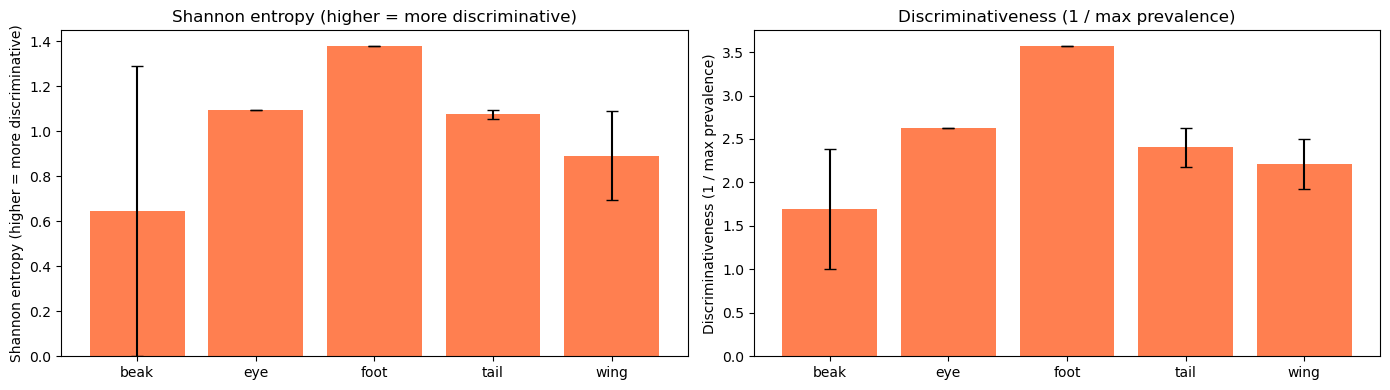

Part attribute discriminativeness:


,part_attr,part,n_unique_values,max_prevalence,col_entropy,discriminativeness
3,foot.model,foot,4,0.28,1.378796,3.571429
1,beak.model,beak,4,0.42,1.290909,2.380952
2,eye.model,eye,3,0.38,1.093493,2.631579
4,tail.color,tail,3,0.38,1.093493,2.631579
6,wing.color,wing,3,0.40,1.087566,2.500000
5,tail.model,tail,3,0.46,1.054930,2.173913
7,wing.model,wing,2,0.52,0.692347,1.923077
0,beak.color,beak,1,1.00,0.000000,1.000000


In [13]:
# ── CELL 13: Attribute discriminativeness ────────────────────────────────────
#
# For each (part, attribute, value): discriminativeness = 1 / prevalence
# High discriminativeness = few classes share it = more unique.
# Also compute per-column entropy (a column with all unique values is maximally discriminative).

from scipy.stats import entropy as scipy_entropy

discrim_rows = []
for col in class_wide.columns:
    vals = class_wide[col].values
    vc = Counter(vals)
    probs = np.array(list(vc.values())) / len(vals)
    col_entropy = float(scipy_entropy(probs))   # high = more discriminative
    n_unique = len(vc)
    max_prev  = max(probs)
    discrim_rows.append({
        "part_attr": col,
        "part": col.split(".")[0],
        "n_unique_values": n_unique,
        "max_prevalence": max_prev,
        "col_entropy": col_entropy,
        "discriminativeness": 1.0 / max_prev,  # inverse of most common value's prevalence
    })

discrim_df = pd.DataFrame(discrim_rows).sort_values("col_entropy", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, label in [
    (axes[0], "col_entropy", "Shannon entropy (higher = more discriminative)"),
    (axes[1], "discriminativeness", "Discriminativeness (1 / max prevalence)"),
]:
    parts_order = sorted(discrim_df["part"].unique())
    data = [discrim_df[discrim_df["part"]==p][metric].values for p in parts_order]
    ax.bar(range(len(parts_order)), [np.mean(d) for d in data], yerr=[np.std(d) for d in data],
           tick_label=parts_order, capsize=4, color="coral")
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.show()

print("Part attribute discriminativeness:")
display(discrim_df)

In [14]:
# ── CELL 14: Layer ordering + probe-JSON helpers ─────────────────────────────
LAYERS_ORDERED = [
    "conv1",
    "layer1.0","layer1.1","layer1.2",
    "layer2.0","layer2.1","layer2.2","layer2.3",
    "layer3.0","layer3.1","layer3.2","layer3.3","layer3.4","layer3.5",
    "layer4.0","layer4.1","layer4.2",
    "avgpool",
]
layer_to_idx = {l: i for i, l in enumerate(LAYERS_ORDERED)}

assert LAYERS_ORDERED[-1] == "avgpool"
assert layer_to_idx["avgpool"] == 17

def ffill_bfill(vals: np.ndarray) -> np.ndarray:
    return pd.Series(vals).ffill().bfill().to_numpy()

def sharp_rise_idx(curve_vals: np.ndarray) -> int:
    v = curve_vals.astype(float)
    if np.all(np.isnan(v)):
        return -1
    v = ffill_bfill(v)
    diffs = np.diff(v)
    return int(np.argmax(diffs)) + 1

print("Layers:", LAYERS_ORDERED)

Layers: ['conv1', 'layer1.0', 'layer1.1', 'layer1.2', 'layer2.0', 'layer2.1', 'layer2.2', 'layer2.3', 'layer3.0', 'layer3.1', 'layer3.2', 'layer3.3', 'layer3.4', 'layer3.5', 'layer4.0', 'layer4.1', 'layer4.2', 'avgpool']


In [20]:
# ── CELL 15: Load probe JSONs ────────────────────────────────────────────────
def load_probe_json(path: Path, model_name: str) -> pd.DataFrame:
    assert path.exists(), f"Missing probe JSON: {path}"
    data = json.loads(path.read_text())
    assert isinstance(data, list), f"Expected list, got {type(data)}"
    df = pd.DataFrame(data)
    df["model"] = model_name
    return df

df_all = None

if BASELINE_JSON.exists() and CBM_JSON.exists():
    df_all = pd.concat(
        [load_probe_json(BASELINE_JSON, "baseline"),
         load_probe_json(CBM_JSON, "cbm")],
        ignore_index=True,
    )

    df_all["layer"] = df_all["layer"].astype(str)
    unknown = sorted(set(df_all["layer"].unique()) - set(LAYERS_ORDERED))
    if unknown:
        print(f"WARNING: layers in JSON not in LAYERS_ORDERED: {unknown}")
        df_all = df_all[df_all["layer"].isin(LAYERS_ORDERED)].copy()

    df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

    # Add missing columns with defaults so downstream cells don't crash
    if "group" not in df_all.columns:
        # derive group from target_name prefix if possible, else use target_name
        df_all["group"] = df_all.get("target_name", pd.Series("unknown", index=df_all.index))
    if "target_type" not in df_all.columns:
        df_all["target_type"] = "attribute"
    if "target_name" not in df_all.columns:
        df_all["target_name"] = "unknown"
    if "best_val_acc" not in df_all.columns:
        # try common alternative column names
        for alt in ["val_acc", "acc", "accuracy", "test_acc"]:
            if alt in df_all.columns:
                df_all["best_val_acc"] = df_all[alt]
                break
        else:
            raise KeyError(f"Cannot find accuracy column. Available: {list(df_all.columns)}")

    df_all = df_all.groupby(
        ["model", "target_type", "target_name", "group", "layer"], as_index=False
    )["best_val_acc"].max()
    df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

    print("Loaded df_all:", df_all.shape)
    print("Models:", df_all["model"].unique())
    print("target_types:", df_all["target_type"].unique())
    print("Sample target_names:", df_all["target_name"].unique()[:10])
    display(df_all.head())
else:
    print("Probe JSONs not found — cells 16–25 and 29–34 will be skipped.")
    print(f"  BASELINE: {BASELINE_JSON}  exists={BASELINE_JSON.exists()}")
    print(f"  CBM:      {CBM_JSON}  exists={CBM_JSON.exists()}")

Loaded df_all: (972, 7)
Models: ['baseline' 'cbm']
target_types: ['attribute' 'subclass']
Sample target_names: ['beak_0' 'beak_1' 'beak_2' 'beak_3' 'eye_0' 'eye_1' 'eye_2' 'foot_0'
 'foot_1' 'foot_2']


,model,target_type,target_name,group,layer,best_val_acc,layer_idx
0,baseline,attribute,beak_0,beak,avgpool,0.988,17
1,baseline,attribute,beak_0,beak,conv1,0.580,0
2,baseline,attribute,beak_0,beak,layer1.0,0.582,1
3,baseline,attribute,beak_0,beak,layer1.1,0.586,2
4,baseline,attribute,beak_0,beak,layer1.2,0.584,3


In [21]:
# ── CELL 16: get_curve + build emerge_df ─────────────────────────────────────
if df_all is None:
    print("df_all is None — skipping emerge_df build. Run Cell 15 with valid JSON files.")
    emerge_df = pd.DataFrame()
else:
    def get_curve(model: str, target_type: str, target_name: str) -> np.ndarray:
        sub = df_all[
            (df_all["model"] == model) &
            (df_all["target_type"] == target_type) &
            (df_all["target_name"] == target_name)
        ]
        s = sub.set_index("layer")["best_val_acc"]
        return np.array([s.get(l, np.nan) for l in LAYERS_ORDERED], dtype=float)

    targets = df_all[["target_type", "target_name", "group"]].drop_duplicates()

    records = []
    for _, row in targets.iterrows():
        ttype, tname, tgroup = row["target_type"], row["target_name"], row["group"]
        for model in ["baseline", "cbm"]:
            v = get_curve(model, ttype, tname)
            if np.all(np.isnan(v)):
                continue
            si = sharp_rise_idx(v)
            records.append({
                "model": model,
                "target_type": ttype,
                "target_name": tname,
                "group": tgroup,
                "max_acc": float(np.nanmax(v)),
                "emergence_layer": LAYERS_ORDERED[si] if si >= 0 else None,
                "emergence_idx": si,
            })

    emerge_df = pd.DataFrame(records)
    print("emerge_df:", emerge_df.shape)
    print("target_types:", emerge_df["target_type"].value_counts().to_dict())
    display(emerge_df.head(10))

emerge_df: (54, 7)
target_types: {'attribute': 52, 'subclass': 2}


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,beak_0,beak,0.988,layer3.0,8
1,cbm,attribute,beak_0,beak,0.990,layer3.0,8
2,baseline,attribute,beak_1,beak,1.000,layer4.0,14
3,cbm,attribute,beak_1,beak,0.998,layer4.0,14
4,baseline,attribute,beak_2,beak,0.998,layer4.0,14
5,cbm,attribute,beak_2,beak,0.998,layer4.0,14
6,baseline,attribute,beak_3,beak,0.996,layer3.0,8
7,cbm,attribute,beak_3,beak,0.990,layer3.0,8
8,baseline,attribute,eye_0,eye,0.994,layer3.0,8
9,cbm,attribute,eye_0,eye,0.992,layer3.0,8


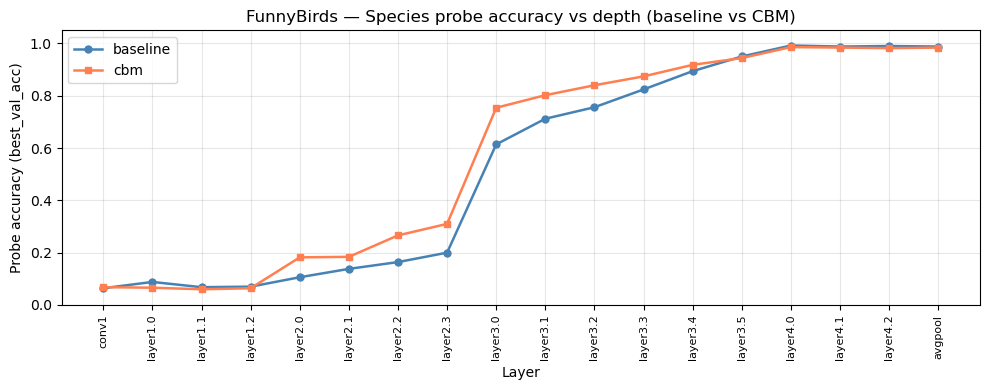

In [23]:
# ── CELL 17: Species probe curve (baseline vs CBM) ───────────────────────────
if df_all is None or emerge_df.empty:
    print("Skipping — probe JSONs not loaded.")
else:
    def plot_two_curves(target_type: str, target_name: str, title=None):
        x = np.arange(len(LAYERS_ORDERED))
        fig, ax = plt.subplots(figsize=(max(10, len(LAYERS_ORDERED)*0.4), 4))
        for model, color, marker in [("baseline","steelblue","o"), ("cbm","coral","s")]:
            v = get_curve(model, target_type, target_name)
            ax.plot(x, v, marker=marker, color=color, label=model, linewidth=1.8, markersize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(LAYERS_ORDERED, rotation=90, fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Probe accuracy (best_val_acc)")
        ax.set_xlabel("Layer")
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_title(title or f"{target_type}: {target_name}")
        plt.tight_layout()
        plt.show()

    plot_two_curves("subclass", "species",
                    title="FunnyBirds — Species probe accuracy vs depth (baseline vs CBM)")

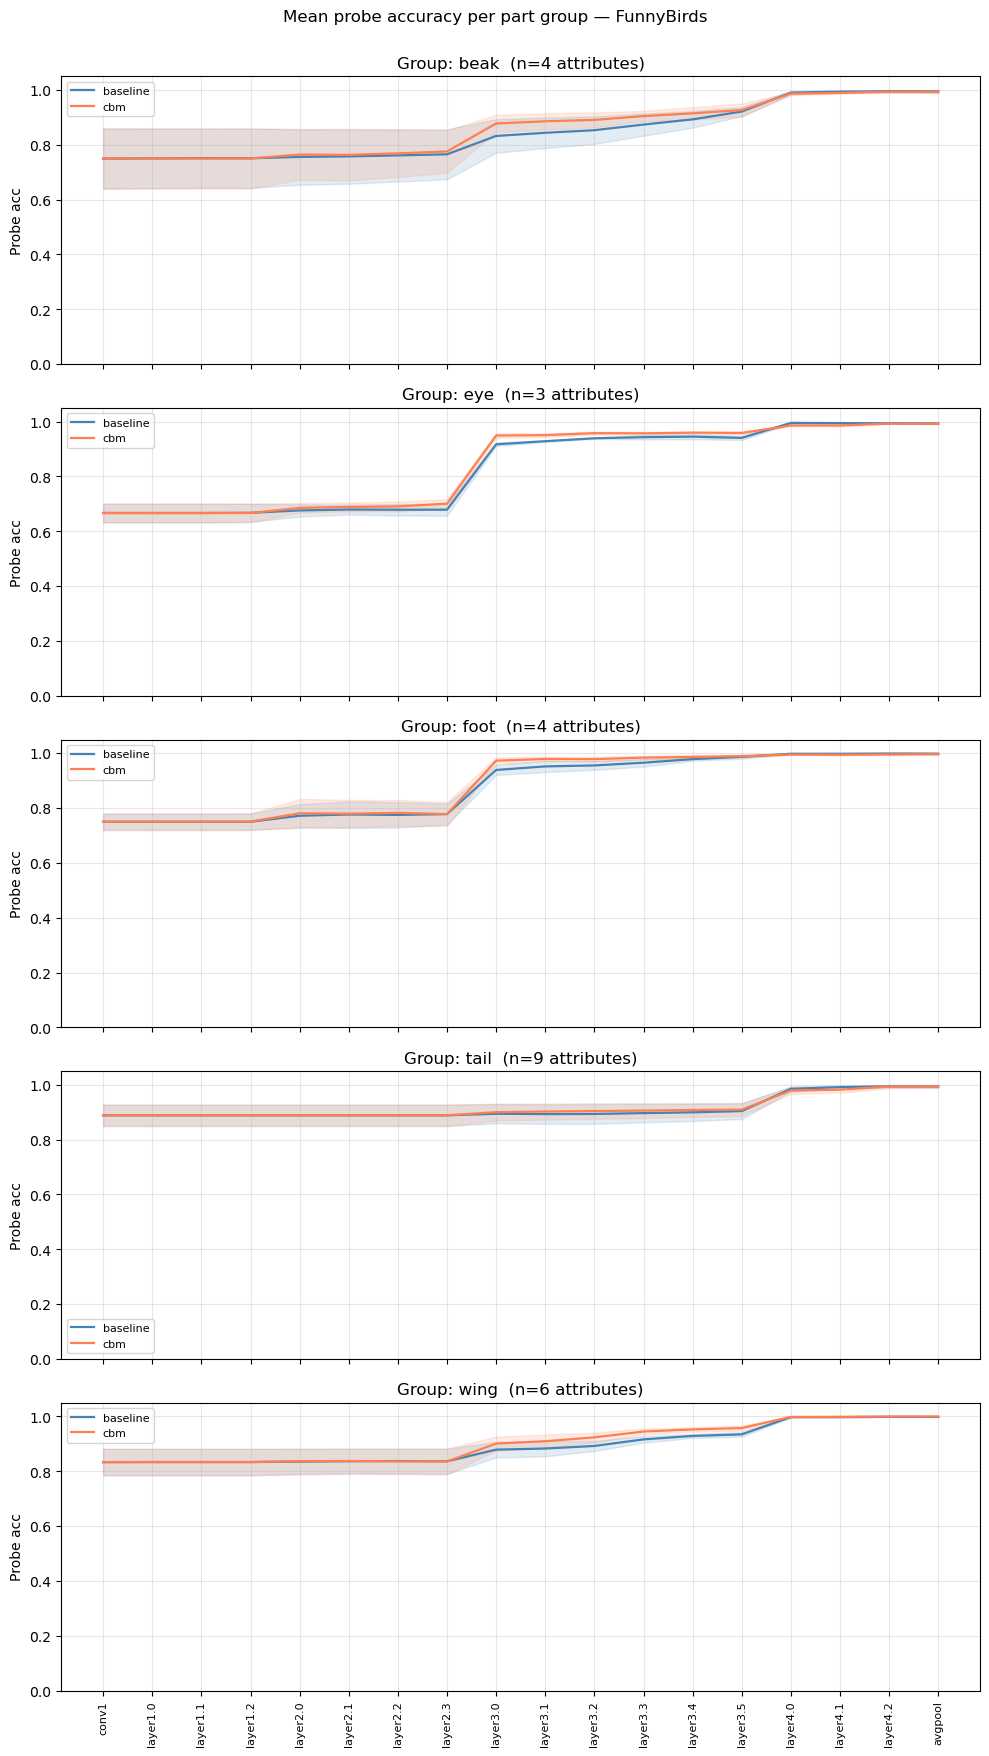

In [24]:
# ── CELL 18: Per-group probe curves ──────────────────────────────────────────
if df_all is None or emerge_df.empty:
    print("Skipping — probe JSONs not loaded.")
else:
    attr_df_probes = df_all[df_all["target_type"] == "attribute"].copy()
    groups = sorted(attr_df_probes["group"].unique())

    fig, axes = plt.subplots(
        len(groups), 1,
        figsize=(max(10, len(LAYERS_ORDERED)*0.35), 3.5*len(groups)),
        sharex=True,
    )
    if len(groups) == 1:
        axes = [axes]

    x = np.arange(len(LAYERS_ORDERED))
    for ax, grp in zip(axes, groups):
        sub = attr_df_probes[attr_df_probes["group"] == grp]
        for model, color in [("baseline","steelblue"), ("cbm","coral")]:
            msub = sub[sub["model"]==model]
            curves = []
            for tname in msub["target_name"].unique():
                v = get_curve(model, "attribute", tname)
                if not np.all(np.isnan(v)):
                    curves.append(ffill_bfill(v))
            if curves:
                arr = np.stack(curves)
                mean = np.nanmean(arr, axis=0)
                std  = np.nanstd(arr, axis=0)
                ax.plot(x, mean, color=color, label=model, linewidth=1.6)
                ax.fill_between(x, mean-std, mean+std, color=color, alpha=0.15)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Probe acc")
        ax.set_title(f"Group: {grp}  (n={sub['target_name'].nunique()} attributes)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(LAYERS_ORDERED, rotation=90, fontsize=8)
    plt.suptitle("Mean probe accuracy per part group — FunnyBirds", y=1.001, fontsize=12)
    plt.tight_layout()
    plt.show()

In [25]:
if df_all is None or emerge_df.empty:
    print("Skipping — probe JSONs not loaded.")
else:
    # original cell content indented here till cell 25 kk?

SyntaxError: incomplete input (1862846892.py, line 4)

/tmp/ipykernel_2923233/2238262016.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(groups_u))


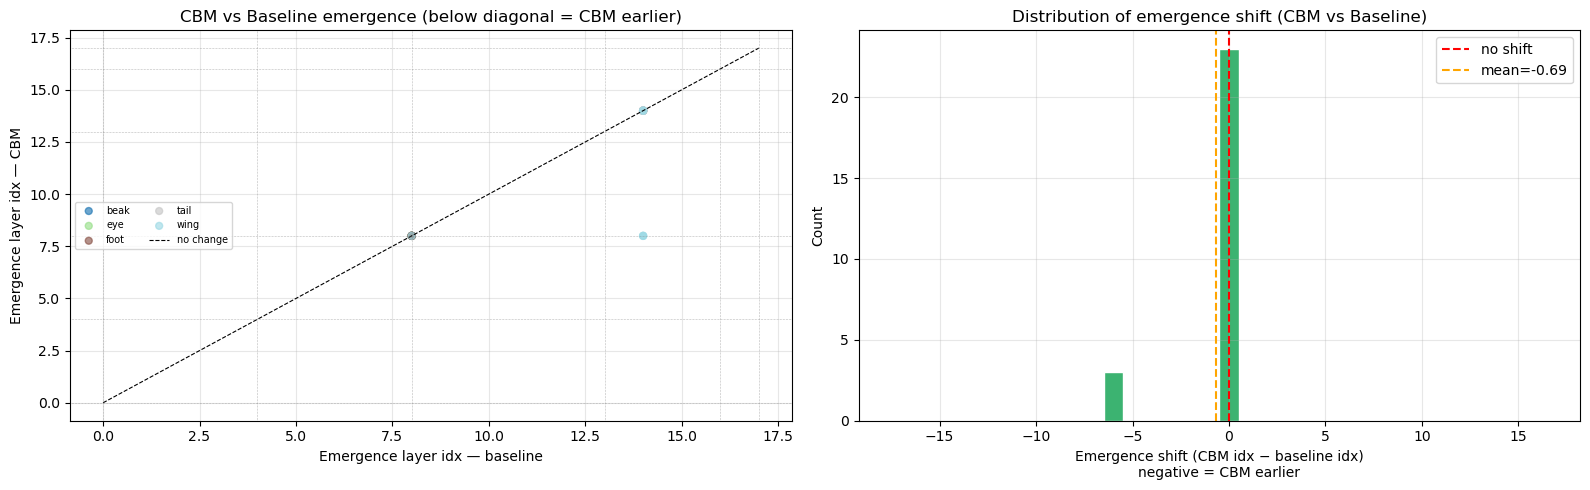

Emergence shift stats (CBM − baseline, negative = CBM is earlier):
count    26.00
mean     -0.69
std       1.95
min      -6.00
25%       0.00
50%       0.00
75%       0.00
max       0.00
Name: shift, dtype: float64

By group:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
beak,4.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
eye,3.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
foot,4.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
tail,9.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
wing,6.0,-3.0,3.29,-6.0,-6.0,-3.0,0.0,0.0


In [31]:
# ── CELL 20: Baseline vs CBM emergence shift ─────────────────────────────────
#
# For each attribute: does CBM shift emergence to earlier or later layers?

both = (
    emerge_df[emerge_df["target_type"] == "attribute"]
    .pivot_table(index=["target_name","group"], columns="model", values="emergence_idx")
    .dropna()
    .reset_index()
)
both["shift"] = both["cbm"] - both["baseline"]   # negative = CBM earlier

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: baseline idx vs cbm idx, coloured by group
groups_u = sorted(both["group"].unique())
cmap = plt.cm.get_cmap("tab20", len(groups_u))
group_to_c = {g: cmap(i) for i, g in enumerate(groups_u)}

ax = axes[0]
for g in groups_u:
    sub = both[both["group"] == g]
    ax.scatter(sub["baseline"], sub["cbm"], c=[group_to_c[g]]*len(sub),
               label=g, alpha=0.65, s=25)
lim_lo, lim_hi = 0, len(LAYERS_ORDERED)-1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=0.8, label="no change")
ax.set_xlabel("Emergence layer idx — baseline")
ax.set_ylabel("Emergence layer idx — CBM")
ax.set_title("CBM vs Baseline emergence (below diagonal = CBM earlier)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
# annotate layer names on axes
for pos in [0, 4, 8, 13, 16, 17]:
    ax.axvline(pos, color="grey", lw=0.4, ls=":")
    ax.axhline(pos, color="grey", lw=0.4, ls=":")

# Histogram of shift
ax = axes[1]
ax.hist(both["shift"], bins=range(-17, 18), align="left", color="mediumseagreen",
        edgecolor="white")
ax.axvline(0, color="red", ls="--", label="no shift")
ax.axvline(both["shift"].mean(), color="orange", ls="--",
           label=f"mean={both['shift'].mean():.2f}")
ax.set_xlabel("Emergence shift (CBM idx − baseline idx)\nnegative = CBM earlier")
ax.set_ylabel("Count")
ax.set_title("Distribution of emergence shift (CBM vs Baseline)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Emergence shift stats (CBM − baseline, negative = CBM is earlier):")
print(both["shift"].describe().round(2))
print()
print("By group:")
display(both.groupby("group")["shift"].describe().round(2))

In [27]:
# ── CELL 21: Part discriminativeness vs emergence layer ──────────────────────
#
# FunnyBirds-specific: does a part that fewer classes share emerge
# earlier or later than a common part?
# Merge emerge_df with discrim_df on part_attr.

# Build a lookup: target_name -> part_attr (need to reconcile naming convention)
# target_name in probe JSON might be "beak_shape::0" or "beak::shape_0" etc.
# Print sample to decide.
print("Sample target_names in emerge_df (attribute):")
print(emerge_df[emerge_df["target_type"]=="attribute"]["target_name"].unique()[:20].tolist())
print()
print("part_attr values in discrim_df:")
print(discrim_df["part_attr"].tolist())

Sample target_names in emerge_df (attribute):
['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']

part_attr values in discrim_df:
['foot.model', 'beak.model', 'eye.model', 'tail.color', 'wing.color', 'tail.model', 'wing.model', 'beak.color']


part  n_variants  emergence_idx  emergence_std  col_entropy  max_prevalence
beak           4           11.0       3.464102     0.645454            0.71
 eye           3            8.0       0.000000     1.093493            0.38
foot           4            8.0       0.000000     1.378796            0.28
tail           9           14.0       0.000000     1.074212            0.42
wing           6           13.0       2.449490     0.889956            0.46


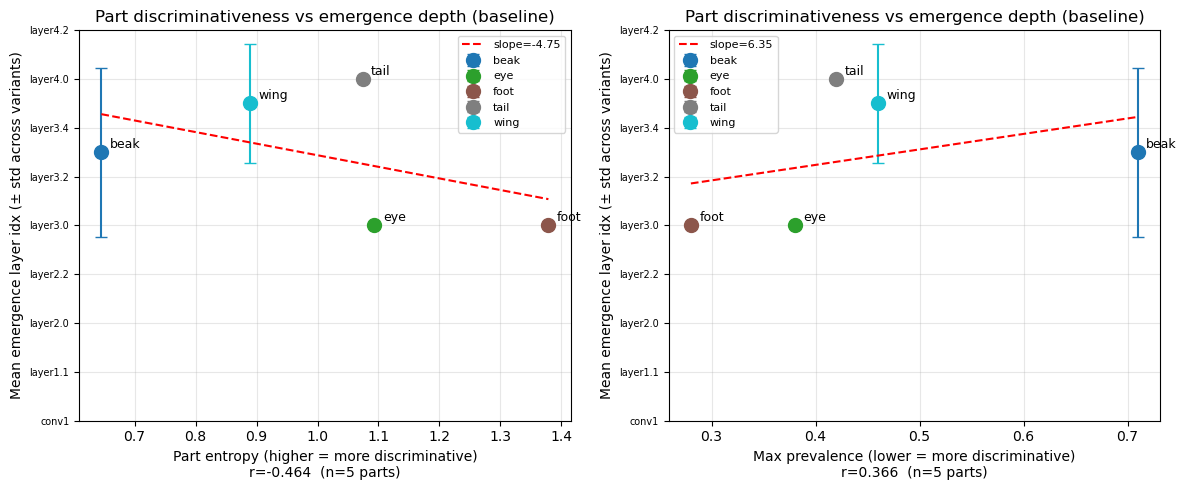


  corr(col_entropy, emergence_idx) = -0.464  (n=5 parts)
  corr(discriminativeness, emergence_idx) = -0.583  (n=5 parts)
  corr(max_prevalence, emergence_idx) = 0.366  (n=5 parts)


In [54]:
# ── CELL 21b: Part discriminativeness vs emergence layer ─────────────────────

def target_name_to_part(tname: str):
    for p in PART_NAMES + ["background"]:
        if tname.startswith(p + "_") or tname == p:
            return p
    return None

attr_emerge_b = emerge_df[
    (emerge_df["target_type"] == "attribute") & (emerge_df["model"] == "baseline")
].copy()
attr_emerge_b["part"] = attr_emerge_b["target_name"].map(target_name_to_part)

unrecognised = attr_emerge_b[attr_emerge_b["part"].isna()]["target_name"].unique()
if len(unrecognised):
    print(f"[warn] unmapped target_names: {unrecognised}")

# Discriminativeness averaged across model/color attributes per part
discrim_part = (
    discrim_df
    .assign(part=discrim_df["part_attr"].str.split(".").str[0])
    .groupby("part")[["col_entropy", "discriminativeness", "max_prevalence"]]
    .mean()
    .reset_index()
)

# One row per part: mean emergence across all variants of that part
merged = attr_emerge_b.merge(discrim_part, on="part", how="left")
m_agg = (
    merged.groupby("part")
    .agg(
        emergence_idx  = ("emergence_idx",   "mean"),
        emergence_std  = ("emergence_idx",   "std"),
        n_variants     = ("emergence_idx",   "size"),
        col_entropy    = ("col_entropy",     "first"),
        discriminativeness = ("discriminativeness", "first"),
        max_prevalence = ("max_prevalence",  "first"),
        max_acc        = ("max_acc",         "mean"),
    )
    .reset_index()
)
print(m_agg[["part","n_variants","emergence_idx","emergence_std",
             "col_entropy","max_prevalence"]].to_string(index=False))

parts_u = sorted(m_agg["part"].unique())
cmap = plt.colormaps["tab10"].resampled(len(parts_u))
part_color = {p: cmap(i) for i, p in enumerate(parts_u)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, xcol, xlabel in [
    (axes[0], "col_entropy",    "Part entropy (higher = more discriminative)"),
    (axes[1], "max_prevalence", "Max prevalence (lower = more discriminative)"),
]:
    sub = m_agg.dropna(subset=[xcol, "emergence_idx"])
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue

    for _, row in sub.iterrows():
        ax.errorbar(
            row[xcol], row["emergence_idx"],
            yerr=row["emergence_std"] if not np.isnan(row["emergence_std"]) else 0,
            fmt="o", color=part_color[row["part"]],
            markersize=10, capsize=4, label=row["part"],
        )
        ax.annotate(
            row["part"],
            (row[xcol], row["emergence_idx"]),
            textcoords="offset points", xytext=(6, 3), fontsize=9,
        )

    if len(sub) > 2:
        z  = np.polyfit(sub[xcol], sub["emergence_idx"], 1)
        xr = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ax.plot(xr, np.polyval(z, xr), "r--", lw=1.5, label=f"slope={z[0]:.2f}")
        corr = np.corrcoef(sub[xcol], sub["emergence_idx"])[0, 1]
        ax.set_xlabel(f"{xlabel}\nr={corr:.3f}  (n={len(sub)} parts)")
    else:
        ax.set_xlabel(xlabel)

    ax.set_ylabel("Mean emergence layer idx (± std across variants)")
    ax.set_yticks(range(0, len(LAYERS_ORDERED), 2))
    ax.set_yticklabels(LAYERS_ORDERED[::2], fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_title("Part discriminativeness vs emergence depth (baseline)")

plt.tight_layout()
plt.show()

print()
for xcol in ["col_entropy", "discriminativeness", "max_prevalence"]:
    sub = m_agg.dropna(subset=[xcol, "emergence_idx"])
    if len(sub) > 1:
        corr = np.corrcoef(sub[xcol], sub["emergence_idx"])[0, 1]
        print(f"  corr({xcol}, emergence_idx) = {corr:.3f}  (n={len(sub)} parts)")

In [36]:
# ── CELL 22: Species emergence reference point ───────────────────────────────

species_info = []
for model in ["baseline", "cbm"]:
    v = get_curve(model, "subclass", "species")
    si = sharp_rise_idx(v)
    species_info.append({
        "model": model,
        "species_idx": si,
        "species_layer": LAYERS_ORDERED[si] if si >= 0 else None,
        "species_max_acc": float(np.nanmax(v)),
        "boundary": (
            f"{LAYERS_ORDERED[si-1]} → {LAYERS_ORDERED[si]}"
            if si > 0 else "N/A"
        ),
    })

species_df = pd.DataFrame(species_info)
display(species_df)

SP_REF_MODEL = "baseline"
SP_IDX = int(species_df.loc[species_df["model"]==SP_REF_MODEL, "species_idx"].iloc[0])
SP_LAYER = LAYERS_ORDERED[SP_IDX]
print(f"\nReference: species emerges at {SP_LAYER} (idx={SP_IDX}) in {SP_REF_MODEL}")

,model,species_idx,species_layer,species_max_acc,boundary
0,baseline,8,layer3.0,0.992,layer2.3 → layer3.0
1,cbm,8,layer3.0,0.986,layer2.3 → layer3.0



Reference: species emerges at layer3.0 (idx=8) in baseline


In [37]:
# ── CELL 23: Attribute boundary-jump table (FunnyBirds version of CUB cell 24)
#
# jump_at_species_boundary = acc[SP_IDX] - acc[SP_IDX-1]
# Measures whether a part probe jumps right where species jumps.

def boundary_jump(v: np.ndarray, idx: int) -> float:
    vf = ffill_bfill(v)
    if idx <= 0 or idx >= len(vf):
        return float("nan")
    return float(vf[idx] - vf[idx - 1])

attr_names = (
    df_all[df_all["target_type"]=="attribute"]["target_name"].drop_duplicates().tolist()
)

bj_rows = []
for a in attr_names:
    grp = df_all.loc[df_all["target_name"]==a, "group"].iloc[0]
    for model in ["baseline", "cbm"]:
        v = get_curve(model, "attribute", a)
        si = sharp_rise_idx(v)
        bj_rows.append({
            "attr": a,
            "group": grp,
            "model": model,
            "attr_sharp_rise_idx": si,
            "attr_sharp_rise_layer": LAYERS_ORDERED[si] if si >= 0 else None,
            "attr_max_acc": float(np.nanmax(v)),
            "jump_at_species_boundary": boundary_jump(v, SP_IDX),
        })

bj_df = pd.DataFrame(bj_rows)
bj_df["at_or_after_species"] = bj_df["attr_sharp_rise_idx"] >= SP_IDX

base_bj = bj_df[bj_df["model"]=="baseline"].copy()

print("Attributes with biggest jump AT the species boundary:")
display(
    base_bj.sort_values("jump_at_species_boundary", ascending=False)
    .head(20)[["attr","group","attr_sharp_rise_layer","attr_max_acc","jump_at_species_boundary"]]
)

Attributes with biggest jump AT the species boundary:


,attr,group,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary
12,eye_2,eye,layer3.0,1.000,0.276
10,eye_1,eye,layer3.0,0.994,0.232
18,foot_2,foot,layer3.0,1.000,0.228
8,eye_0,eye,layer3.0,0.994,0.208
20,foot_3,foot,layer3.0,0.996,0.192
6,beak_3,beak,layer3.0,0.996,0.126
16,foot_1,foot,layer3.0,1.000,0.122
0,beak_0,beak,layer3.0,0.988,0.106
14,foot_0,foot,layer3.0,1.000,0.102
42,wing_1,wing,layer3.0,0.998,0.076


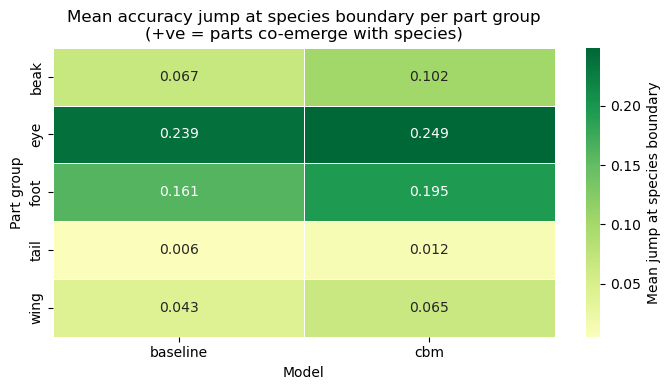

In [38]:
# ── CELL 24: Species-boundary heatmap by part group ──────────────────────────
#
# Mean jump-at-species-boundary per group × model — quick visual summary.

pivot_bj = (
    bj_df.groupby(["group","model"])["jump_at_species_boundary"]
    .mean()
    .unstack("model")
)

fig, ax = plt.subplots(figsize=(7, max(4, len(pivot_bj)*0.45)))
sns.heatmap(pivot_bj, ax=ax, annot=True, fmt=".3f", cmap="RdYlGn",
            center=0, linewidths=0.5, cbar_kws={"label": "Mean jump at species boundary"})
ax.set_title("Mean accuracy jump at species boundary per part group\n(+ve = parts co-emerge with species)")
ax.set_xlabel("Model")
ax.set_ylabel("Part group")
plt.tight_layout()
plt.show()

In [39]:
# ── CELL 25: Class-pair confusability analysis (FunnyBirds-unique) ───────────
#
# In FunnyBirds, classes that share a part value should be hardest to
# distinguish on that part's probe.  Find class pairs that differ on
# exactly ONE part attribute — the "minimum distinguishing pair".

min_diff_pairs = pair_df[pair_df["differ_on"] == pair_df["differ_on"].min()].copy()
print(f"Pairs differing on minimum number of parts ({pair_df['differ_on'].min()}):")
display(min_diff_pairs)

max_shared = pair_df["shared"].max()
hard_pairs = pair_df[pair_df["shared"] == max_shared].copy()
print(f"\nHardest pairs (share {max_shared} out of {n_attrs} part values):")
display(hard_pairs[["class_A","class_B","shared","differ_on","diff_parts"]].head(20))

# For each hard pair: what is the probe accuracy at the distinguishing part?
print("\n--- Probe accuracy for the distinguishing parts of the hardest pairs ---")
for _, row in hard_pairs.head(5).iterrows():
    ci, cj = int(row["class_A"]), int(row["class_B"])
    diff_parts_str = row["diff_parts"]
    print(f"\nPair ({ci}, {cj}) — differ on: {diff_parts_str}")
    for pa in diff_parts_str.split(", ")[:3]:
        # find probe target_names belonging to this part_attr
        matches = bj_df[bj_df["group"].str.contains(pa.split(".")[0], case=False, na=False)]
        if not matches.empty:
            for _, m in matches[matches["model"]=="baseline"].head(3).iterrows():
                print(f"  attr={m['attr']}  max_acc={m['attr_max_acc']:.3f}  "
                      f"emerge@{m['attr_sharp_rise_layer']}")

Pairs differing on minimum number of parts (1):


,class_A,class_B,shared,differ_on,diff_parts
976,27,32,7,1,tail.color
1191,41,44,7,1,foot.model
458,10,24,7,1,wing.model
1173,39,43,7,1,beak.model
153,3,13,7,1,wing.color
356,7,42,7,1,foot.model
746,18,36,7,1,beak.model
584,13,39,7,1,tail.color
1031,29,46,7,1,eye.model



Hardest pairs (share 7 out of 8 part values):


,class_A,class_B,shared,differ_on,diff_parts
976,27,32,7,1,tail.color
1191,41,44,7,1,foot.model
458,10,24,7,1,wing.model
1173,39,43,7,1,beak.model
153,3,13,7,1,wing.color
356,7,42,7,1,foot.model
746,18,36,7,1,beak.model
584,13,39,7,1,tail.color
1031,29,46,7,1,eye.model



--- Probe accuracy for the distinguishing parts of the hardest pairs ---

Pair (27, 32) — differ on: tail.color
  attr=tail_0  max_acc=1.000  emerge@layer4.0
  attr=tail_1  max_acc=0.992  emerge@layer4.0
  attr=tail_2  max_acc=0.996  emerge@layer4.0

Pair (41, 44) — differ on: foot.model
  attr=foot_0  max_acc=1.000  emerge@layer3.0
  attr=foot_1  max_acc=1.000  emerge@layer3.0
  attr=foot_2  max_acc=1.000  emerge@layer3.0

Pair (10, 24) — differ on: wing.model
  attr=wing_0  max_acc=1.000  emerge@layer4.0
  attr=wing_1  max_acc=0.998  emerge@layer3.0
  attr=wing_2  max_acc=1.000  emerge@layer4.0

Pair (39, 43) — differ on: beak.model
  attr=beak_0  max_acc=0.988  emerge@layer3.0
  attr=beak_1  max_acc=1.000  emerge@layer4.0
  attr=beak_2  max_acc=0.998  emerge@layer4.0

Pair (3, 13) — differ on: wing.color
  attr=wing_0  max_acc=1.000  emerge@layer4.0
  attr=wing_1  max_acc=0.998  emerge@layer3.0
  attr=wing_2  max_acc=1.000  emerge@layer4.0


In [40]:
# ── CELL 26: Per-class accuracy from features ────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

LAYER_TO_PROBE = "layer4.0"

def _safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def load_split_ids_and_labels(feat_dir: Path, split: str):
    lbl_path = feat_dir / f"labels_{split}.pt"
    assert lbl_path.exists(), f"Missing {lbl_path}"
    d = _safe_torch_load(lbl_path)
    assert "image_ids" in d, f"{lbl_path} has keys: {list(d.keys())}"
    img_ids = np.asarray(d["image_ids"]).reshape(-1).astype(int)
    # "labels" key may not exist if feature extraction only saved image_ids + species_ids
    if "labels" in d:
        labels = np.asarray(d["labels"]).reshape(-1).astype(int)
    elif "species_ids" in d:
        labels = np.asarray(d["species_ids"]).reshape(-1).astype(int)
    else:
        # derive labels from img_df using image_ids
        id2cls = img_df.set_index("image_id")["class_id"].to_dict()
        labels = np.array([id2cls.get(int(i), -1) for i in img_ids], dtype=int)
    return img_ids, labels

train_ids = test_ids = None

if BASELINE_FEAT_DIR.exists():
    train_ids, train_labels = load_split_ids_and_labels(BASELINE_FEAT_DIR, "train")
    test_ids,  test_labels  = load_split_ids_and_labels(BASELINE_FEAT_DIR, "test")
    print("Train:", len(train_ids), "images | classes:", np.unique(train_labels).size)
    print("Test: ", len(test_ids),  "images | classes:", np.unique(test_labels).size)
else:
    print("Feature directory not found:", BASELINE_FEAT_DIR)
    print("Run feature extraction first. Skipping feature-level cells.")

Train: 50000 images | classes: 50
Test:  500 images | classes: 50


[layer4.0] Species probe test accuracy: 0.9860


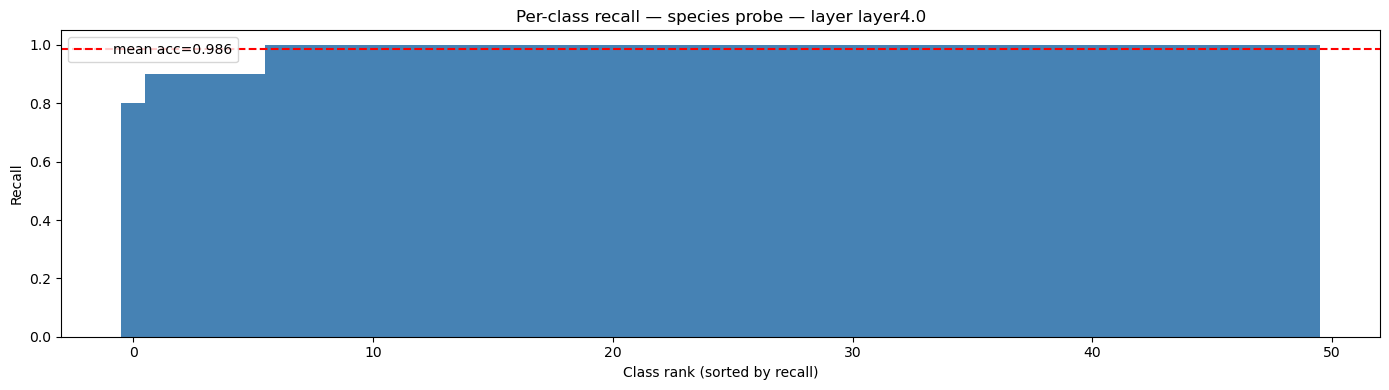

Per-class recall (worst 10):


,class_id,n,recall
3,3,10,0.8
24,24,10,0.9
48,48,10,0.9
22,22,10,0.9
13,13,10,0.9
2,2,10,0.9
45,45,10,1.0
47,47,10,1.0
29,29,10,1.0
30,30,10,1.0


In [41]:
# ── CELL 27: Train probe and compute per-class recall ────────────────────────
if train_ids is None:
    print("Skipping — feature files not loaded (Cell 26).")
else:
    def gather_Xy(X, img_ids, gt_img, id_col="image_id", label_col="class_id"):
        id_to_row = {int(iid): i for i, iid in enumerate(img_ids)}
        gt_img = gt_img.drop_duplicates(id_col)
        gt_img = gt_img[gt_img[id_col].isin(id_to_row)]
        rows = [id_to_row[int(i)] for i in gt_img[id_col]]
        Xsub = X[rows].float()
        ysub = torch.tensor(gt_img[label_col].values, dtype=torch.long)
        return Xsub, ysub, gt_img[id_col].values

    def train_probe_cls(Xtr, ytr, num_classes, epochs=15, lr=1e-3, wd=1e-4, seed=0):
        torch.manual_seed(seed)
        probe = nn.Linear(Xtr.shape[1], num_classes)
        opt   = optim.Adam(probe.parameters(), lr=lr, weight_decay=wd)
        loss_fn = nn.CrossEntropyLoss()
        probe.train()
        for _ in range(epochs):
            opt.zero_grad()
            loss = loss_fn(probe(Xtr), ytr)
            loss.backward()
            opt.step()
        return probe

    def eval_probe_cls(probe, Xte, yte):
        probe.eval()
        with torch.no_grad():
            pred = probe(Xte).argmax(dim=1).numpy()
        y_np = yte.numpy()
        return pred, y_np, float((pred == y_np).mean())

    Xtr = _safe_torch_load(BASELINE_FEAT_DIR / f"{LAYER_TO_PROBE}_train.pt")
    Xte = _safe_torch_load(BASELINE_FEAT_DIR / f"{LAYER_TO_PROBE}_test.pt")

    train_img_df = img_df[img_df["split"] == "train"][["image_id","class_id"]].copy()
    test_img_df  = img_df[img_df["split"] == "test"][["image_id","class_id"]].copy()

    Xtr_s, ytr_s, _ = gather_Xy(Xtr, train_ids, train_img_df)
    Xte_s, yte_s, _ = gather_Xy(Xte, test_ids,  test_img_df)

    n_classes = img_df["class_id"].nunique()
    probe_cls = train_probe_cls(Xtr_s, ytr_s, n_classes)
    pred_s, true_s, acc_s = eval_probe_cls(probe_cls, Xte_s, yte_s)

    print(f"[{LAYER_TO_PROBE}] Species probe test accuracy: {acc_s:.4f}")

    per_class_recall = []
    for cls in sorted(np.unique(true_s)):
        mask = (true_s == cls)
        per_class_recall.append({"class_id": cls, "n": int(mask.sum()),
                                  "recall": float((pred_s[mask] == true_s[mask]).mean())})
    per_class_recall = pd.DataFrame(per_class_recall).sort_values("recall")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(per_class_recall)), per_class_recall["recall"].values,
           color="steelblue", width=1.0)
    ax.set_xlabel("Class rank (sorted by recall)")
    ax.set_ylabel("Recall")
    ax.set_title(f"Per-class recall — species probe — layer {LAYER_TO_PROBE}")
    ax.axhline(acc_s, color="red", ls="--", label=f"mean acc={acc_s:.3f}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Per-class recall (worst 10):")
    display(per_class_recall.head(10))

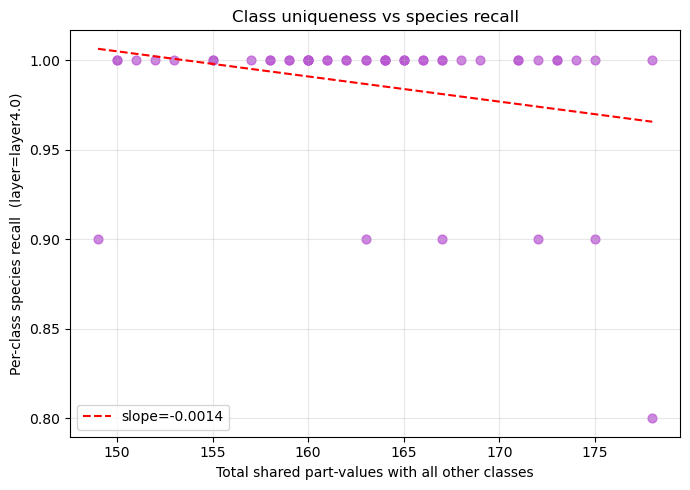

Pearson r(total_shared_parts, recall) = -0.257


In [42]:
# ── CELL 28: Per-class recall joined to class structure ──────────────────────
if train_ids is None:
    print("Skipping — feature files not loaded.")
else:
    # original content unchanged
    avg_sim = pd.Series(
        {cls: sim_matrix[i, :].sum() - sim_matrix[i, i]
         for i, cls in enumerate(classes)},
        name="total_shared_parts"
    )
    recall_vs_sim = (
        per_class_recall.set_index("class_id")
        .join(avg_sim, how="left")
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(recall_vs_sim["total_shared_parts"], recall_vs_sim["recall"],
               alpha=0.7, s=40, color="mediumorchid")
    valid = recall_vs_sim["total_shared_parts"].notna()
    z = np.polyfit(recall_vs_sim.loc[valid, "total_shared_parts"],
                   recall_vs_sim.loc[valid, "recall"], 1)
    xr = np.linspace(recall_vs_sim["total_shared_parts"].min(),
                     recall_vs_sim["total_shared_parts"].max(), 100)
    ax.plot(xr, np.polyval(z, xr), "r--", lw=1.5, label=f"slope={z[0]:.4f}")
    ax.set_xlabel("Total shared part-values with all other classes")
    ax.set_ylabel(f"Per-class species recall  (layer={LAYER_TO_PROBE})")
    ax.set_title("Class uniqueness vs species recall")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    corr = recall_vs_sim[["total_shared_parts","recall"]].dropna().corr().iloc[0,1]
    print(f"Pearson r(total_shared_parts, recall) = {corr:.3f}")

/tmp/ipykernel_2923233/105491452.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(groups_u)+1)
/tmp/ipykernel_2923233/105491452.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(groups_u)+1)


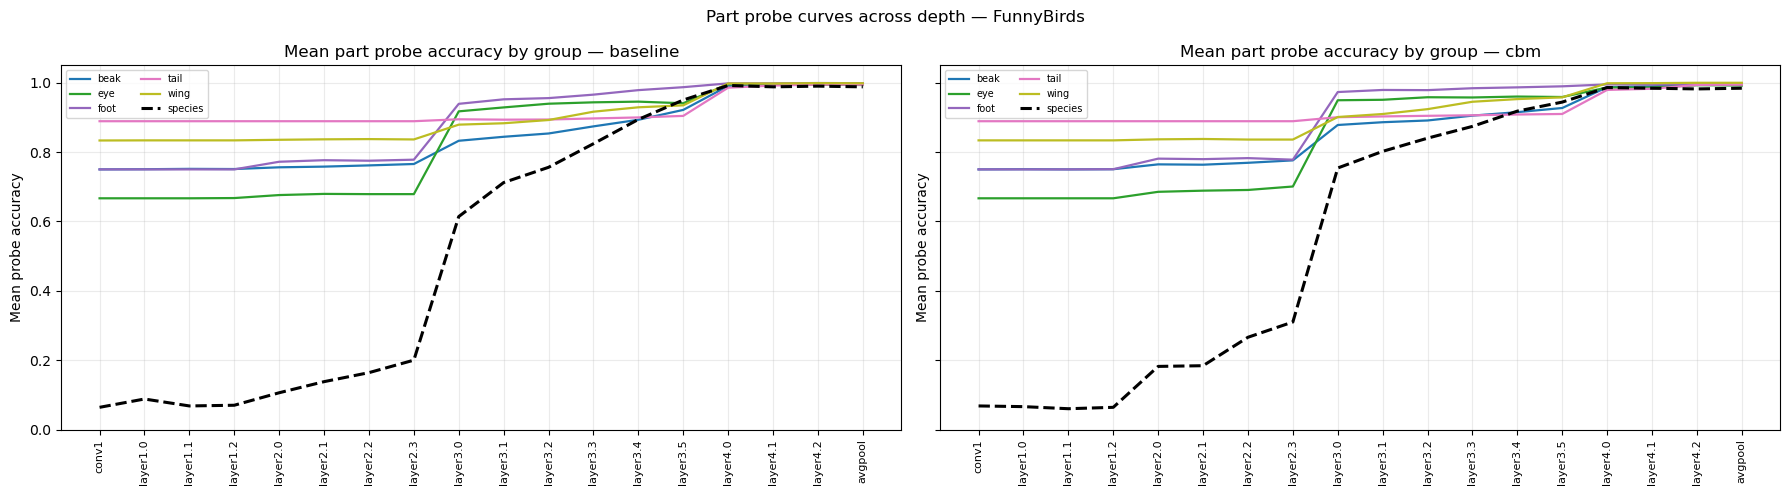

In [43]:
# ── CELL 29: Probe accuracy vs layer — all part groups stacked ───────────────
#
# Single panel: mean accuracy per group per layer, as coloured lines.
# Good for seeing which group saturates earliest.

x = np.arange(len(LAYERS_ORDERED))
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, model in zip(axes, ["baseline", "cbm"]):
    msub = df_all[(df_all["model"]==model) & (df_all["target_type"]=="attribute")]
    groups_u = sorted(msub["group"].unique())
    cmap = plt.cm.get_cmap("tab20", len(groups_u)+1)

    for gi, grp in enumerate(groups_u):
        gsub = msub[msub["group"]==grp]
        curves = []
        for tname in gsub["target_name"].unique():
            v = get_curve(model, "attribute", tname)
            if not np.all(np.isnan(v)):
                curves.append(ffill_bfill(v))
        if curves:
            mean = np.nanmean(np.stack(curves), axis=0)
            ax.plot(x, mean, color=cmap(gi), label=grp, linewidth=1.6)

    # add species
    v_sp = get_curve(model, "subclass", "species")
    ax.plot(x, ffill_bfill(v_sp), color="black", lw=2.2, ls="--", label="species")

    ax.set_xticks(x)
    ax.set_xticklabels(LAYERS_ORDERED, rotation=90, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean probe accuracy")
    ax.set_title(f"Mean part probe accuracy by group — {model}")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, ncol=2)

plt.suptitle("Part probe curves across depth — FunnyBirds", fontsize=12)
plt.tight_layout()
plt.show()

In [44]:
# ── CELL 30: Summary table — per group emergence statistics ──────────────────

grp_summary = []
for model in ["baseline", "cbm"]:
    sub = emerge_df[(emerge_df["target_type"]=="attribute") & (emerge_df["model"]==model)]
    for grp in sorted(sub["group"].unique()):
        gsub = sub[sub["group"]==grp]
        sp_row = species_df[species_df["model"]==model].iloc[0]
        sp_idx = int(sp_row["species_idx"])

        grp_summary.append({
            "model": model,
            "group": grp,
            "n_attrs": len(gsub),
            "mean_emerge_idx": gsub["emergence_idx"].mean(),
            "median_emerge_idx": gsub["emergence_idx"].median(),
            "mean_max_acc": gsub["max_acc"].mean(),
            "frac_before_species": (gsub["emergence_idx"] < sp_idx).mean(),
            "frac_at_species": (gsub["emergence_idx"] == sp_idx).mean(),
            "frac_after_species": (gsub["emergence_idx"] > sp_idx).mean(),
            "species_idx": sp_idx,
            "species_layer": sp_row["species_layer"],
        })

grp_summ_df = pd.DataFrame(grp_summary)

print("=== Part group emergence summary ===")
display(grp_summ_df.sort_values(["model","mean_emerge_idx"]))

=== Part group emergence summary ===


,model,group,n_attrs,mean_emerge_idx,median_emerge_idx,mean_max_acc,frac_before_species,frac_at_species,frac_after_species,species_idx,species_layer
1,baseline,eye,3,8.0,8.0,0.996000,0.0,1.000000,0.000000,8,layer3.0
2,baseline,foot,4,8.0,8.0,0.999000,0.0,1.000000,0.000000,8,layer3.0
0,baseline,beak,4,11.0,11.0,0.995500,0.0,0.500000,0.500000,8,layer3.0
4,baseline,wing,6,13.0,14.0,0.999333,0.0,0.166667,0.833333,8,layer3.0
3,baseline,tail,9,14.0,14.0,0.994889,0.0,0.000000,1.000000,8,layer3.0
6,cbm,eye,3,8.0,8.0,0.992667,0.0,1.000000,0.000000,8,layer3.0
7,cbm,foot,4,8.0,8.0,0.997000,0.0,1.000000,0.000000,8,layer3.0
9,cbm,wing,6,10.0,8.0,0.999667,0.0,0.666667,0.333333,8,layer3.0
5,cbm,beak,4,11.0,11.0,0.994000,0.0,0.500000,0.500000,8,layer3.0
8,cbm,tail,9,14.0,14.0,0.994222,0.0,0.000000,1.000000,8,layer3.0


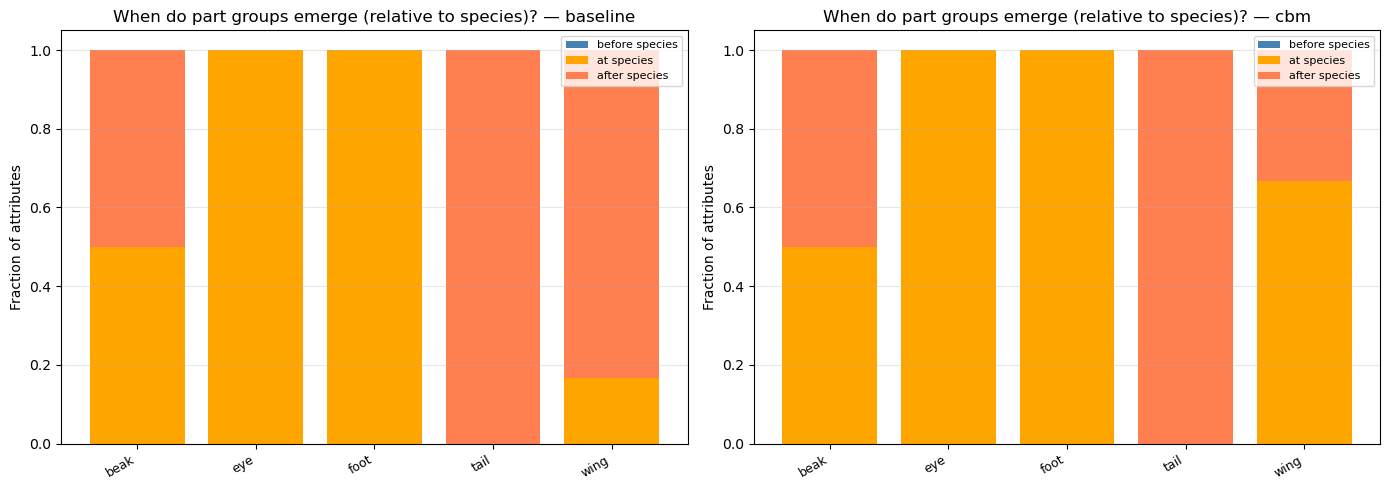

In [45]:
# ── CELL 31: Before/at/after species breakdown (stacked bar) ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model in zip(axes, ["baseline", "cbm"]):
    sub = grp_summ_df[grp_summ_df["model"]==model].sort_values("frac_before_species")
    grps = sub["group"].tolist()
    x    = np.arange(len(grps))
    ax.bar(x, sub["frac_before_species"],  label="before species", color="steelblue")
    ax.bar(x, sub["frac_at_species"],      label="at species",
           bottom=sub["frac_before_species"], color="orange")
    ax.bar(x, sub["frac_after_species"],   label="after species",
           bottom=sub["frac_before_species"]+sub["frac_at_species"], color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(grps, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Fraction of attributes")
    ax.set_title(f"When do part groups emerge (relative to species)? — {model}")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

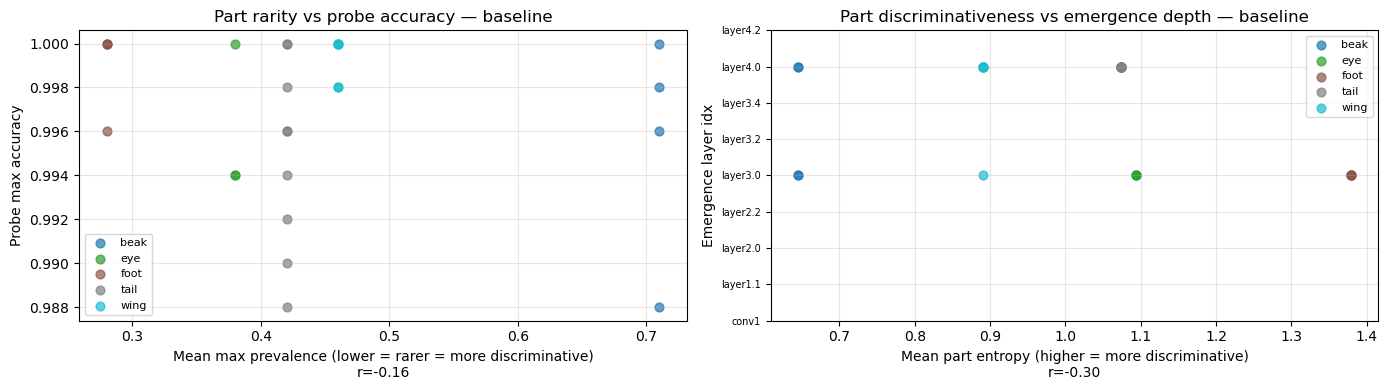

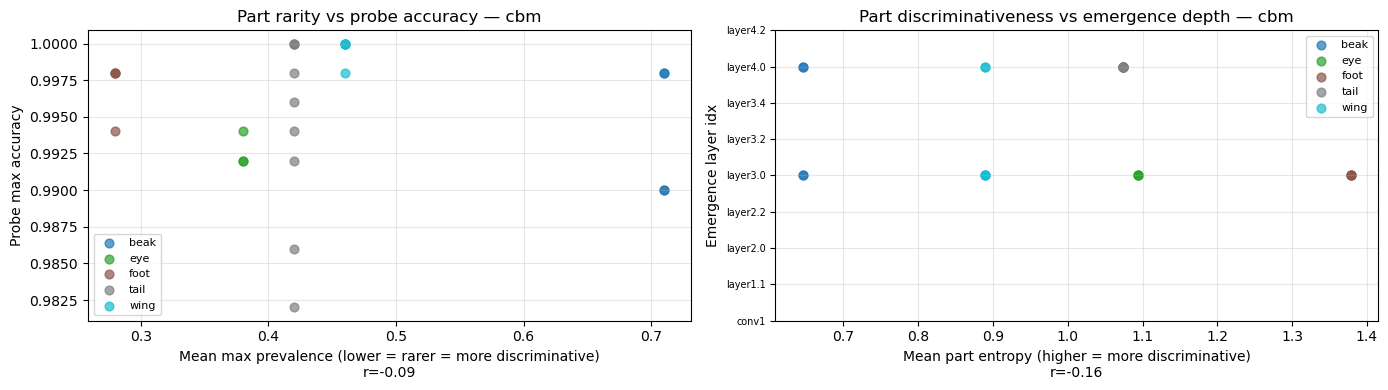

In [49]:
# ── CELL 32: Probe accuracy vs part discriminativeness ───────────────────────
if df_all is None or emerge_df.empty:
    print("Skipping — probe JSONs not loaded.")
else:
    # Same part-level merge as Cell 21b
    discrim_part = (
        discrim_df
        .assign(part=discrim_df["part_attr"].str.split(".").str[0])
        .groupby("part")[["col_entropy", "discriminativeness", "max_prevalence"]]
        .mean()
        .reset_index()
    )

    for model in ["baseline", "cbm"]:
        attr_e = emerge_df[
            (emerge_df["target_type"] == "attribute") &
            (emerge_df["model"] == model)
        ].copy()
        attr_e["part"] = attr_e["target_name"].map(target_name_to_part)
        m = attr_e.merge(discrim_part, on="part", how="left")
        m = m.dropna(subset=["max_prevalence"])

        if m.empty:
            print(f"[{model}] No data after merge — skipping plots.")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        parts_u = sorted(m["part"].dropna().unique())
        cmap = plt.colormaps["tab10"].resampled(max(len(parts_u), 1))
        part_to_color = {p: cmap(i) for i, p in enumerate(parts_u)}

        # Panel 1: max_prevalence vs max_acc
        ax = axes[0]
        for p in parts_u:
            gsub = m[m["part"] == p]
            ax.scatter(gsub["max_prevalence"], gsub["max_acc"],
                       color=part_to_color[p], label=p, alpha=0.7, s=40)
        ax.set_xlabel("Mean max prevalence (lower = rarer = more discriminative)")
        ax.set_ylabel("Probe max accuracy")
        ax.set_title(f"Part rarity vs probe accuracy — {model}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if len(m) > 1:
            corr = np.corrcoef(m["max_prevalence"], m["max_acc"])[0, 1]
            ax.set_xlabel(ax.get_xlabel() + f"\nr={corr:.2f}")

        # Panel 2: col_entropy vs emergence_idx
        ax = axes[1]
        for p in parts_u:
            gsub = m[m["part"] == p]
            ax.scatter(gsub["col_entropy"], gsub["emergence_idx"],
                       color=part_to_color[p], label=p, alpha=0.7, s=40)
        ax.set_xlabel("Mean part entropy (higher = more discriminative)")
        ax.set_ylabel("Emergence layer idx")
        ax.set_yticks(range(0, len(LAYERS_ORDERED), 2))
        ax.set_yticklabels(LAYERS_ORDERED[::2], fontsize=7)
        ax.set_title(f"Part discriminativeness vs emergence depth — {model}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if len(m) > 1:
            corr2 = np.corrcoef(m["col_entropy"], m["emergence_idx"])[0, 1]
            ax.set_xlabel(ax.get_xlabel() + f"\nr={corr2:.2f}")

        plt.tight_layout()
        plt.show()

/tmp/ipykernel_2923233/1977237054.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(groups_u))


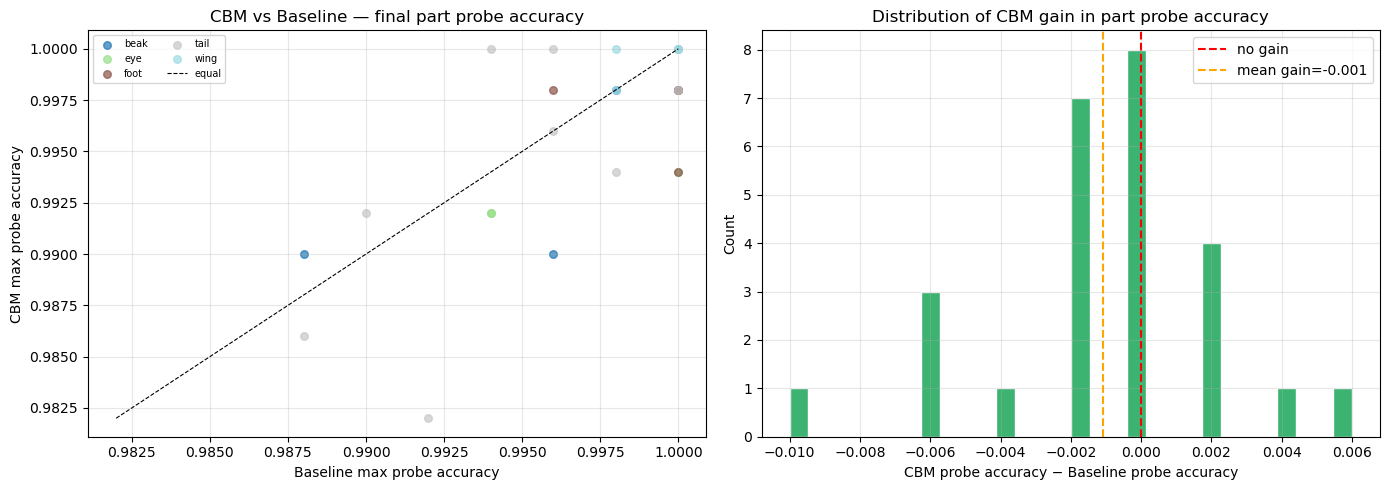

CBM gain stats (positive = CBM is better at probing parts):
count    26.0000
mean     -0.0011
std       0.0034
min      -0.0100
25%      -0.0020
50%       0.0000
75%       0.0000
max       0.0060
Name: cbm_gain, dtype: float64

By group:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
beak,4.0,-0.0015,0.0034,-0.006,-0.003,-0.001,0.0005,0.002
eye,3.0,-0.0033,0.0023,-0.006,-0.004,-0.002,-0.0020,-0.002
foot,4.0,-0.0020,0.0033,-0.006,-0.003,-0.002,-0.0010,0.002
tail,9.0,-0.0007,0.0047,-0.010,-0.002,0.000,0.0020,0.006
wing,6.0,0.0003,0.0008,0.000,0.000,0.000,0.0000,0.002


In [50]:
# ── CELL 33: CBM part-probe final accuracy vs baseline ───────────────────────
#
# For each attribute: does CBM give higher final probe accuracy?
# (The CBM is supposed to make parts more linearly decodable.)

final_acc = (
    emerge_df[emerge_df["target_type"]=="attribute"]
    .pivot_table(index=["target_name","group"], columns="model", values="max_acc")
    .dropna()
    .reset_index()
)
final_acc["cbm_gain"] = final_acc["cbm"] - final_acc["baseline"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
groups_u = sorted(final_acc["group"].unique())
cmap = plt.cm.get_cmap("tab20", len(groups_u))
for gi, grp in enumerate(groups_u):
    gsub = final_acc[final_acc["group"]==grp]
    ax.scatter(gsub["baseline"], gsub["cbm"],
               color=cmap(gi), label=grp, alpha=0.7, s=30)
lo, hi = final_acc[["baseline","cbm"]].min().min(), final_acc[["baseline","cbm"]].max().max()
ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="equal")
ax.set_xlabel("Baseline max probe accuracy")
ax.set_ylabel("CBM max probe accuracy")
ax.set_title("CBM vs Baseline — final part probe accuracy")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(final_acc["cbm_gain"], bins=30, color="mediumseagreen", edgecolor="white")
ax.axvline(0, color="red", ls="--", label="no gain")
ax.axvline(final_acc["cbm_gain"].mean(), color="orange", ls="--",
           label=f"mean gain={final_acc['cbm_gain'].mean():.3f}")
ax.set_xlabel("CBM probe accuracy − Baseline probe accuracy")
ax.set_ylabel("Count")
ax.set_title("Distribution of CBM gain in part probe accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("CBM gain stats (positive = CBM is better at probing parts):")
print(final_acc["cbm_gain"].describe().round(4))
print()
print("By group:")
display(final_acc.groupby("group")["cbm_gain"].describe().round(4))